In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_percentage_error

from prophet import Prophet
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
import itertools

import warnings
warnings.filterwarnings('ignore')

In [23]:
# Load the data
df_train = pd.read_csv("./dataset/train.csv")
df_fullfilment = pd.read_csv("./dataset/fulfilment_center_info.csv")
df_meal = pd.read_csv("./dataset/meal_info.csv")
df_test = pd.read_csv("./dataset/test.csv")

In [24]:
print(f"Train data: {df_train.shape}")
print(f"Test data: {df_test.shape}")
print(f"Fullfilment_center_info data: {df_fullfilment.shape}")
print(f"Meal_info data: {df_meal.shape}")

Train data: (456548, 9)
Test data: (32573, 8)
Fullfilment_center_info data: (77, 5)
Meal_info data: (51, 3)


In [25]:
df_train.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [26]:
df_test.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured
0,1028232,146,55,1885,158.11,159.11,0,0
1,1127204,146,55,1993,160.11,159.11,0,0
2,1212707,146,55,2539,157.14,159.14,0,0
3,1082698,146,55,2631,162.02,162.02,0,0
4,1400926,146,55,1248,163.93,163.93,0,0


In [27]:
df_fullfilment.head()

,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


In [28]:
df_meal.head()

,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian


In [29]:
df_train.describe()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000


In [30]:
df_train.isnull().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
dtype: int64

In [31]:
print(df_train.shape)
df = df_train.merge(df_fullfilment, on="center_id", how='left')
df = df.merge(df_meal, on="meal_id", how="left")
print(df.shape)

(456548, 9)
(456548, 15)


In [32]:
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian


In [33]:
df_temp = df.groupby(by="category").agg({"cuisine": "nunique"}).reset_index()
df_temp

,category,cuisine
0,Beverages,4
1,Biryani,1
2,Desert,1
3,Extras,1
4,Fish,1
5,Other Snacks,1
6,Pasta,1
7,Pizza,1
8,Rice Bowl,1
9,Salad,1


### Observation
* Other than 'Beverages', all other categories are unique to their cuisine

In [34]:
df_temp = df.groupby(by="center_id").agg({"cuisine": "nunique"}).reset_index().sort_values('cuisine')
df_temp['cuisine'].min(), df_temp['cuisine'].max(), df_temp['cuisine'].mean(), df_temp['cuisine'].median()

(np.int64(4), np.int64(4), np.float64(4.0), np.float64(4.0))

In [35]:
df_temp = df.groupby(by="center_id").agg({"category": "nunique"}).reset_index().sort_values('category')
df_temp['category'].min(), df_temp['category'].max(), df_temp['category'].mean(), df_temp['category'].median()

(np.int64(11), np.int64(14), np.float64(12.766233766233766), np.float64(12.0))

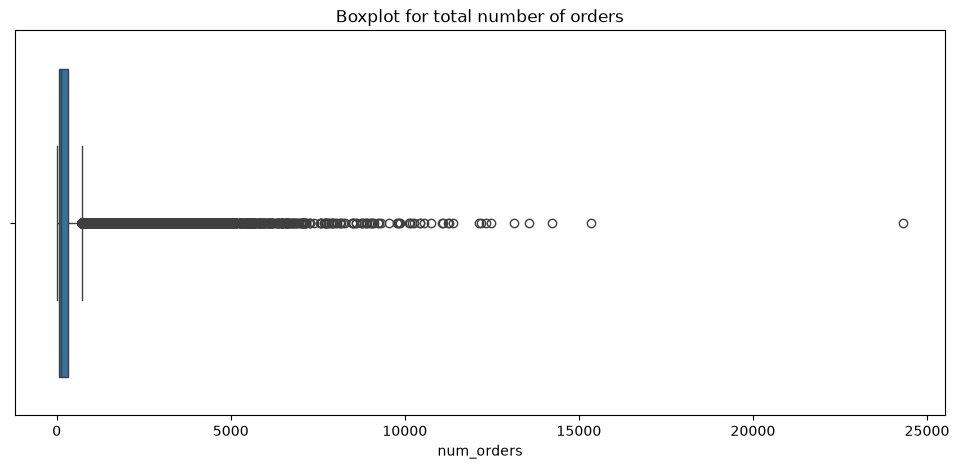

In [36]:
plt.figure(figsize=(12,5))
sns.boxplot(data = df, x="num_orders")
plt.title("Boxplot for total number of orders")
plt.show()

In [37]:
df['center_meal'] = df.apply(lambda x: f"{x['center_id']}_{x['meal_id']}", axis=1)
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,center_meal
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,55_1885
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,55_1993
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,55_2539
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,55_2139
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,55_2631


In [38]:
df['center_id'].nunique(), df['meal_id'].nunique(), df['center_meal'].nunique(), df['city_code'].nunique(), df['region_code'].nunique(), len(df), df['week'].max()

(77, 51, 3597, 51, 8, 456548, np.int64(145))

In [39]:
weeks = range(1, df['week'].max()+1)
df_forecastibility = (
    df.groupby(['center_id', 'meal_id', 'center_meal'])
    .apply(lambda x: pd.Series({
        'total_obs': len(weeks),
        'non_zero_obs': (x['num_orders'] >0).sum(),
        'ADI': (len(weeks)/(x['num_orders']>0).sum() if (x['num_orders']>0).any() else None),
        'CV2': (x.loc[x['num_orders'] > 0, 'num_orders'].std()/ x.loc[x['num_orders'] > 0, 'num_orders'].mean()) **2,
        'cor_baseprice': x['num_orders'].corr(x['base_price']),
        'cor_checkoutprice': x['num_orders'].corr(x['checkout_price']),
        'cor_email': x['num_orders'].corr(x['emailer_for_promotion']),
        'cor_homepage': x['num_orders'].corr(x['homepage_featured'])
    })).reset_index()
)
df_forecastibility['SBC'] = np.select(
    [
        (df_forecastibility['ADI'] < 1.32) & (df_forecastibility['CV2'] < 0.49),
        (df_forecastibility['ADI'] >= 1.32) & (df_forecastibility['CV2'] < 0.49),
        (df_forecastibility['ADI'] < 1.32) & (df_forecastibility['CV2'] >= 0.49),
        (df_forecastibility['ADI'] >= 1.32) & (df_forecastibility['CV2'] >= 0.49)
    ],
    ['Smooth', 'Intermittent', 'Erratic', 'Lumpy'],
    default='NA'
)
df_forecastibility.head()

,center_id,meal_id,center_meal,total_obs,non_zero_obs,ADI,CV2,cor_baseprice,cor_checkoutprice,cor_email,cor_homepage,SBC
0,10,1062,10_1062,145.0,145.0,1.000000,0.075145,0.105204,-0.400973,0.290483,0.215389,Smooth
1,10,1109,10_1109,145.0,145.0,1.000000,0.171756,0.028419,-0.424526,0.797420,0.726589,Smooth
2,10,1198,10_1198,145.0,145.0,1.000000,0.167105,0.291807,0.256622,NaN,0.187330,Smooth
3,10,1207,10_1207,145.0,144.0,1.006944,0.670863,-0.005901,-0.594153,0.388854,0.537746,Erratic
4,10,1216,10_1216,145.0,143.0,1.013986,0.161993,0.031092,-0.312121,0.100416,0.066141,Smooth


In [40]:
df_forecastibility.groupby(by='SBC').agg({'non_zero_obs': ['count', 'min', 'max', 'mean', 'median'] }).round(1)

non_zero_obs                            
                    count    min    max   mean median
SBC                                                  
Erratic              1221  110.0  145.0  137.6  143.0
Intermittent          412    3.0  109.0   70.0   77.0
Lumpy                 199    3.0  109.0   77.7   83.0
NA                      3    1.0    1.0    1.0    1.0
Smooth               1762  110.0  145.0  138.6  144.0

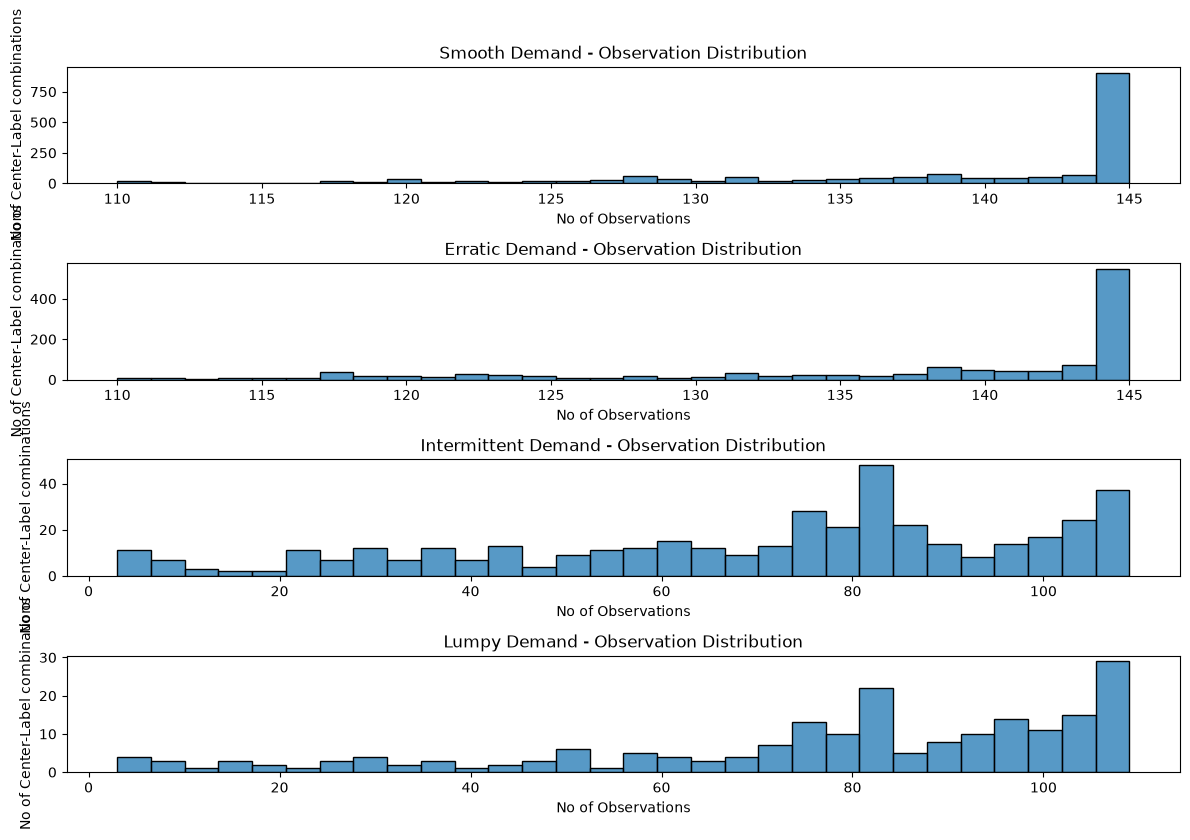

In [41]:
fig, ax = plt.subplots(nrows=4, figsize=(12,8))
for i, sbc in enumerate(['Smooth', 'Erratic', 'Intermittent', 'Lumpy']):
    data = df_forecastibility[df_forecastibility['SBC'] == sbc]
    sns.histplot(data=data, x='non_zero_obs', bins=30,  label="Non-zero Observations", ax=ax[i])
    ax[i].set_title(f"{sbc} Demand - Observation Distribution")
    ax[i].set_xlabel("No of Observations")
    ax[i].set_ylabel("No of Center-Label combinations")
    # ax[i].grid(axis='y', aplpha=0.2)
plt.tight_layout()
plt.show()

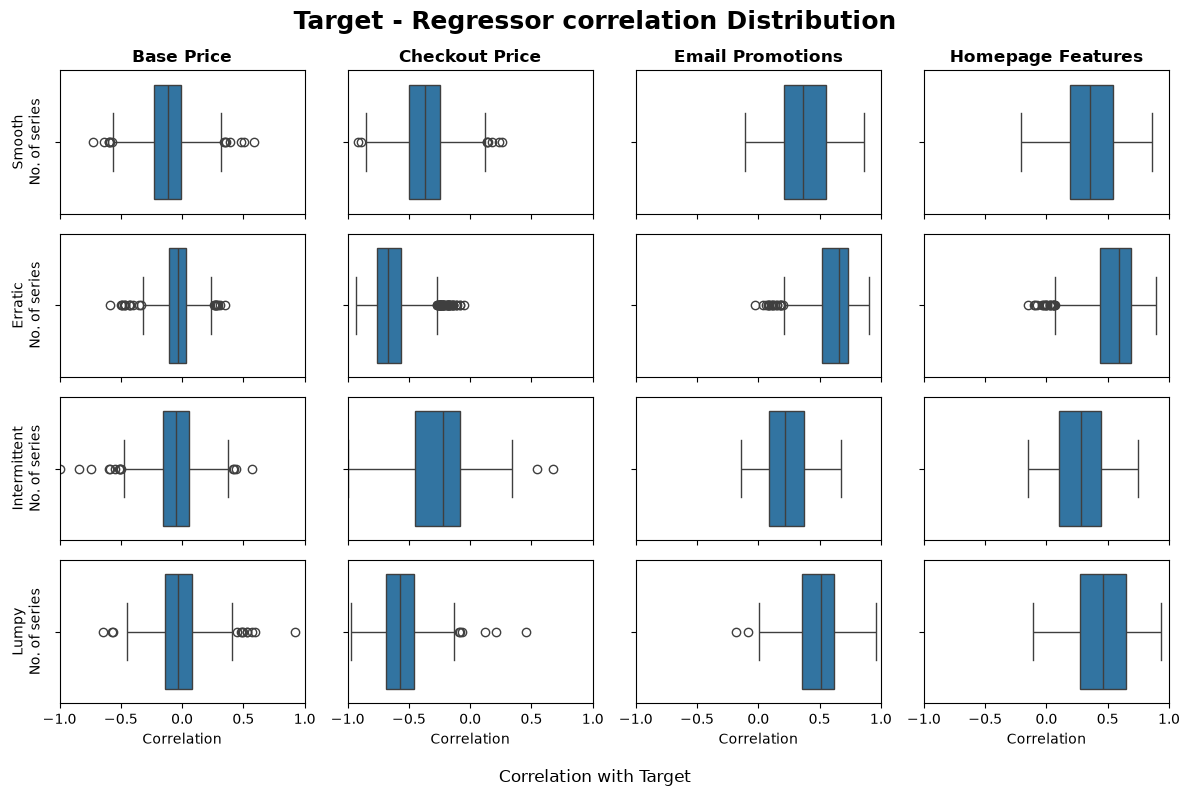

In [42]:
fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(12, 8), sharex=True)

features = {
    'cor_baseprice': 'Base Price',
    'cor_checkoutprice': 'Checkout Price',
    'cor_email': 'Email Promotions',
    'cor_homepage': 'Homepage Features'
}
sbc_cat = ['Smooth', 'Erratic', 'Intermittent', 'Lumpy']

for i, sbc in enumerate(sbc_cat):
    data = df_forecastibility[df_forecastibility['SBC'] == sbc]

    for j, (feature, label) in enumerate(features.items()):
        sns.boxplot(data=data, x=feature, ax=ax[i][j])
        ax[i][j].set_xlim(-1,1)
        if i == 0:
            ax[i][j].set_title(label, fontsize=12, fontweight='bold')
        if j==0:
            ax[i][j].set_ylabel(f"{sbc}\nNo. of series")
        else:
            ax[i][j].set_ylabel("")
        if i == len(sbc_cat) - 1:
            ax[i, j].set_xlabel('Correlation')
        else:
            ax[i, j].set_xlabel('')
fig.suptitle("Target - Regressor correlation Distribution", fontsize=18, fontweight='bold')
fig.supxlabel('Correlation with Target', fontsize=12)
fig.tight_layout()
plt.show()

In [43]:
df_forecastibility.to_csv("./mywork/forecastibility.csv", index=False)

In [44]:
def get_plot(data):
    cntr = data['center_id'].iat[0]
    ml = data['meal_id'].iat[0]
    sbc = data['SBC'].iat[0]

    sns.set_style("whitegrid")
    fig, ax_left = plt.subplots(figsize=(14, 6))
    ax_right = ax_left.twinx()

    sns.lineplot(data=data, x='week', y='num_orders', ax=ax_left, label="No. of Orders", linewidth=2.5, marker='o')
    
    regressors = [
        ('base_price', 'Base Price', 'tab:orange', '-', None),
        ('checkout_price', 'Checkout Price', 'tab:green', '-', None),
        ('emailer_for_promotion', 'Email Promotion', 'tab:red', '--', None),
        ('homepage_featured', 'Homepage Featured', 'tab:purple', '--', None)
    ]
    for col, label, color, style, marker in regressors:
        sns.lineplot(data=data, x='week', y=col, ax=ax_right, label=label, color=color, linestyle=style, linewidth=2, marker=marker)

    ax_left.set_ylabel("Number of Orders", color='tab:blue')
    ax_left.tick_params(axis='y', labelcolor='tab:blue')
    ax_left.set_xlabel('Weeks')
    ax_left.set_title(f"SBC: {sbc} | Center: {cntr} | Meal: {ml}")
    ax_right.set_ylabel("Price / Promotion Variables", fontsize=11)

    plt.show()

In [45]:
df = df.merge(df_forecastibility[['center_meal', 'SBC']], on='center_meal', how='left')
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,center_meal,SBC
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,55_1885,Smooth
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,55_1993,Smooth
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,55_2539,Smooth
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,55_2139,Intermittent
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,55_2631,Smooth


In [46]:
cntr_meal = df_forecastibility[df_forecastibility['non_zero_obs']==145]['center_meal'].unique()
len(cntr_meal)

1247

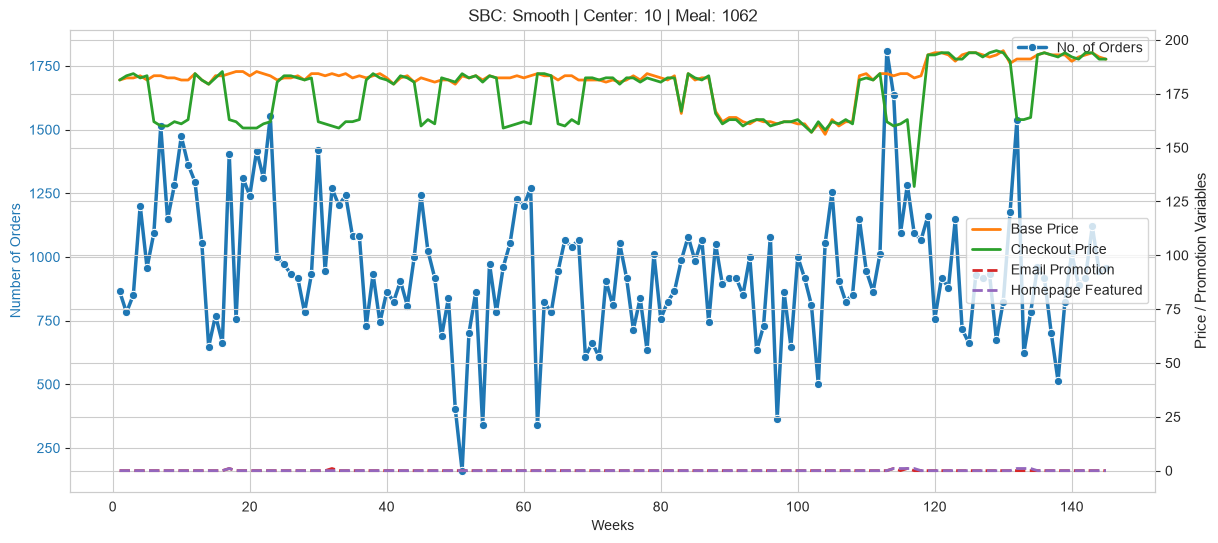

In [47]:
df_temp = df[df['center_meal']==cntr_meal[0]]
get_plot(df_temp)



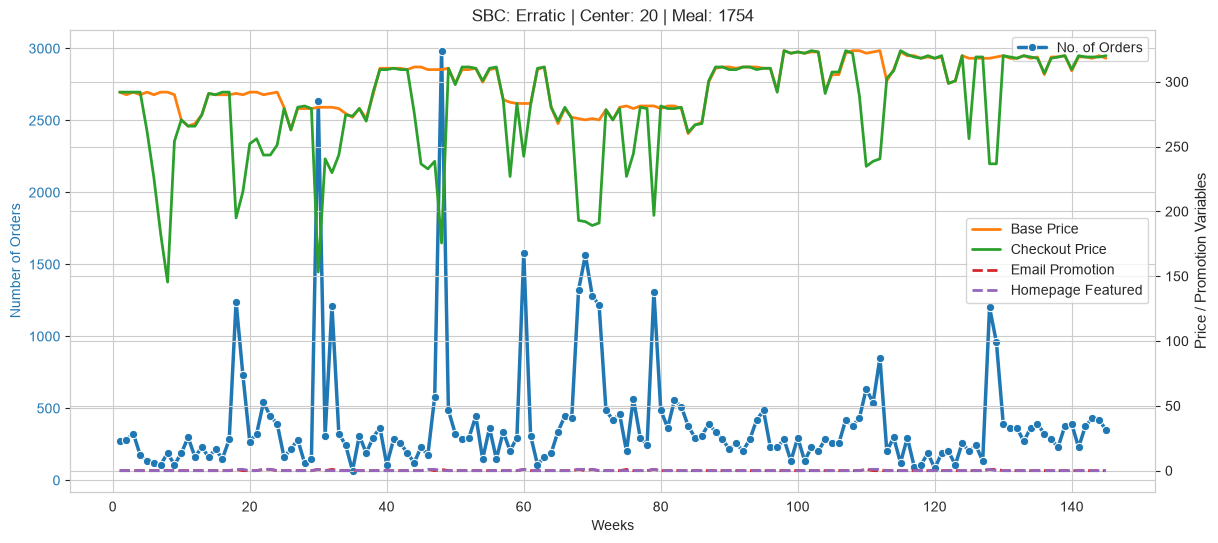

In [48]:
df_temp = df[df['center_meal']==cntr_meal[111]]
get_plot(df_temp)


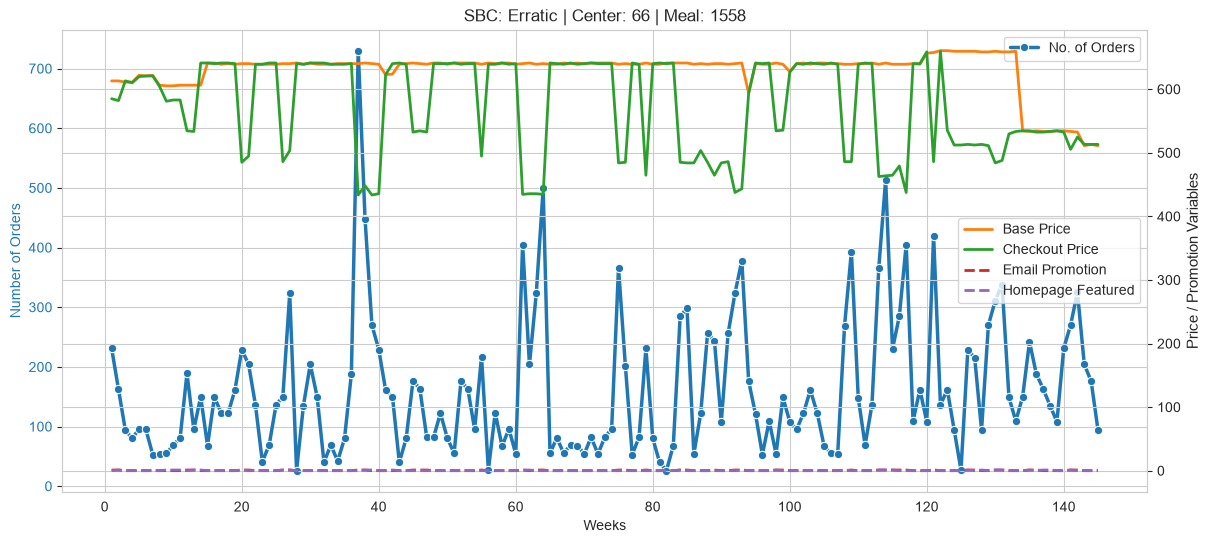

In [49]:
df_temp = df[df['center_meal']==cntr_meal[500]]
get_plot(df_temp)


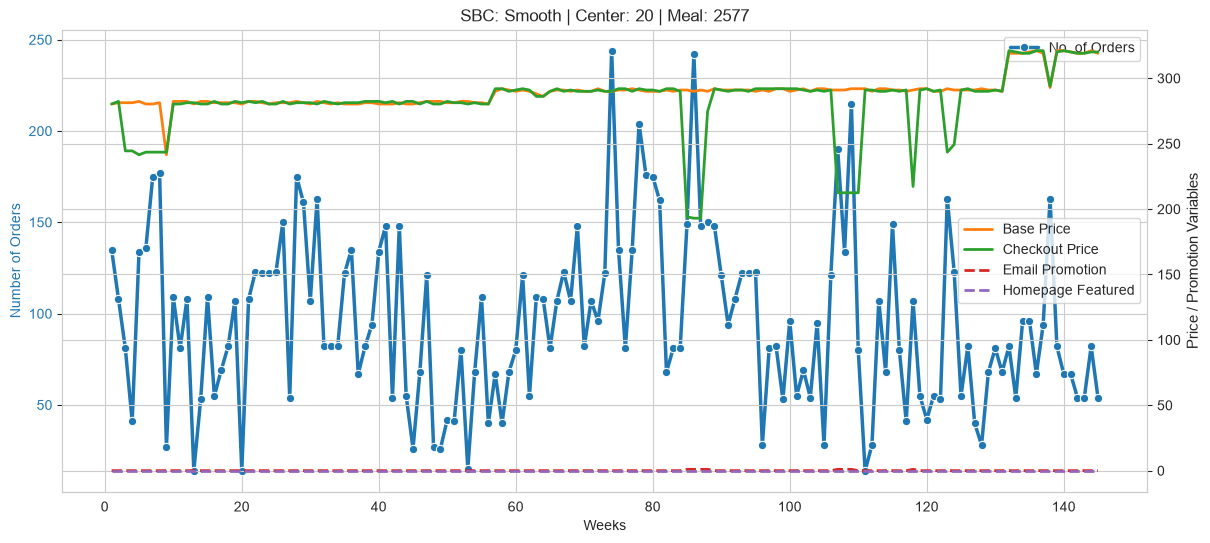

In [50]:
df_temp = df[df['center_meal']==cntr_meal[120]]
get_plot(df_temp)


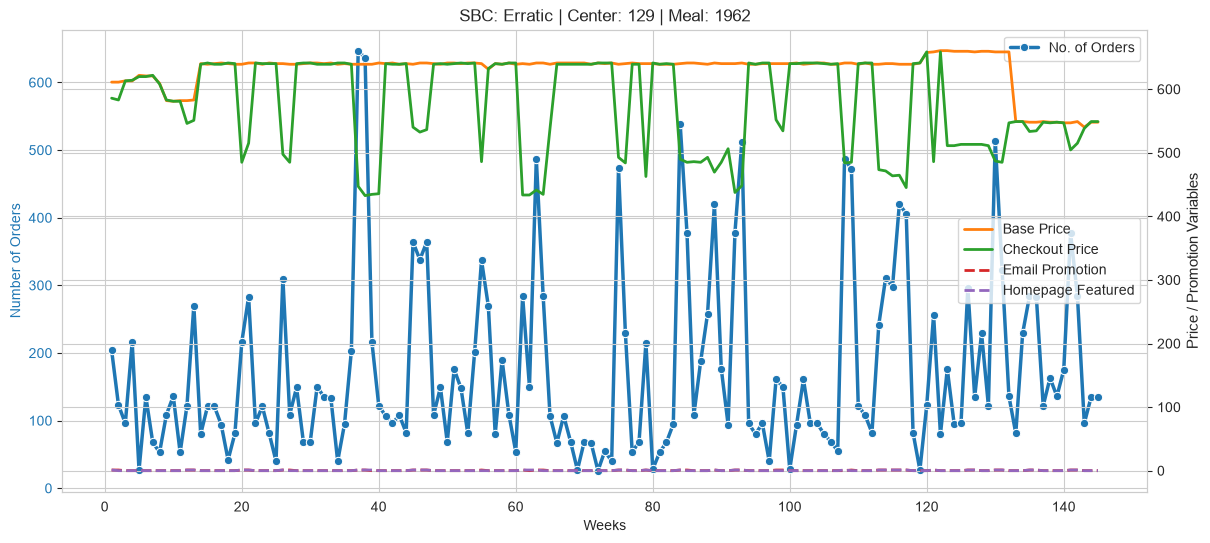

In [51]:
df_temp = df[df['center_meal']==cntr_meal[1000]]
get_plot(df_temp)


In [52]:
df_train['week'].min(), df_train['week'].max(), df_test['week'].min(), df_test['week'].max()

(np.int64(1), np.int64(145), np.int64(146), np.int64(155))

#### Prepare the data for Forecasting
* Lets assume that the data is till December and we are using Monday to calculate date
* this is done so that we can use Prophet model
* Week 155 in dec means week 1 should fall in first monday of 2023 which is 2nd Jan 2023

In [53]:
first_monday = pd.Timestamp('2023-01-02')

# Create week -> date mapping
week_date_map = {week: first_monday + pd.Timedelta(weeks = week-1) for week in range(1, df_test['week'].max()+1)}
df['date'] = df['week'].map(week_date_map)
df_test['date'] = df_test['week'].map(week_date_map)
df_test['center_meal'] = df_test.apply(lambda x: f"{x['center_id']}_{x['meal_id']}", axis=1)
df_test.tail()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,date,center_meal
32568,1250239,155,61,1543,482.09,484.09,0,0,2025-12-15,61_1543
32569,1039516,155,61,2304,483.09,483.09,0,0,2025-12-15,61_2304
32570,1158107,155,61,2664,322.07,323.07,0,0,2025-12-15,61_2664
32571,1444235,155,61,2569,322.07,323.07,0,0,2025-12-15,61_2569
32572,1291286,155,61,2490,276.45,276.45,0,0,2025-12-15,61_2490


In [54]:
def preprocess_data(train_data, test_data, center_meal):
    df_tr = train_data[train_data['center_meal']==center_meal].reset_index(drop=True)
    df_ts = test_data[test_data['center_meal']==center_meal].rename(columns={'date': 'ds'}).reset_index(drop=True)
    df_tr1 = df_tr[['date', 'num_orders']].rename(columns={'date': 'ds', 'num_orders': 'y'})
    scaler = StandardScaler()
    df_tr1[['checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured']] = scaler.fit_transform(
        df_tr[['checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured']]
    )
    df_ts[['checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured']] = scaler.transform(
            df_ts[['checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured']]
        )

    return df_tr1, df_ts

In [55]:
def train_prophet(df_tr, df_ts):

    m = Prophet()
    m.add_regressor('checkout_price')
    m.add_regressor('emailer_for_promotion')
    m.add_regressor('homepage_featured')
    m.fit(df_tr)

    check_forecast = m.predict(df_tr)
    if 'yearly' in check_forecast.columns:
        required_cols = ['ds', 'trend', 'yearly', 'yhat']
    else:
        required_cols = ['ds', 'trend', 'yhat']
    df_tr = df_tr.merge(check_forecast[required_cols], on='ds', how='outer')

    forecast = m.predict(df_ts)
    df_ts = df_ts.merge(forecast[required_cols], on='ds', how='outer')
    performance_info = {
        'center_meal': df_ts['center_meal'].iat[0],
        'r2_score': r2_score(df_tr['y'], df_tr['yhat']),
        'mape': mean_absolute_percentage_error(df_tr['y'], df_tr['yhat'])
    }
    return df_tr, df_ts, performance_info


In [56]:
center_meals = df_test['center_meal'].unique()
df['center_meal'].nunique(), len(center_meals), df_test['center_meal'].nunique()

(3597, 3548, 3548)

In [57]:
performance, test_pred, train_pred, train_pred = [], [], [], []
i=1
for center_meal in center_meals:
    try:
        df_temp, df_temp_ts = preprocess_data(df, df_test, center_meal)
        df_tr1, df_pred, info_dict = train_prophet(df_temp, df_temp_ts)
        performance.append(info_dict)
        test_pred.append(df_pred)
        train_pred.append(df_tr1)
        print(f"{i} of {len(center_meals)} {center_meal} done =================================================================================")
        
    except Exception as e:
        performance.append({
            'center_meal': center_meal,
            'r2_score': None,
            'mape': None,
            'Error': str(e)
        })
        print(f"{i} of {len(center_meals)} {center_meal} Skipped !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
    i+=1

19:15:41 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1] done processing
19:15:42 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1] done processing


1 of 3548 55_1885 done =================================================================================


19:15:42 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1] done processing


2 of 3548 55_1993 done =================================================================================


19:15:42 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1] done processing


...

3546 of 3548 55_1902 done =================================================================================


19:33:17 - cmdstanpy - INFO - Chain [1] done processing
19:33:17 - cmdstanpy - INFO - Chain [1] start processing


3547 of 3548 74_1247 done =================================================================================


19:33:17 - cmdstanpy - INFO - Chain [1] done processing


3548 of 3548 139_2577 done =================================================================================


In [58]:
df_performance = pd.DataFrame(performance)
df_performance.tail()

,center_meal,r2_score,mape,Error
3543,162_1247,0.522258,1.677512e-01,NaN
3544,102_1770,0.467386,1.816970e-01,NaN
3545,55_1902,0.820134,8.590499e-02,NaN
3546,74_1247,0.820276,1.090653e-01,NaN
3547,139_2577,1.000000,4.635407e-09,NaN


In [59]:
df_test1 = pd.concat(test_pred, ignore_index=True)
df_train1 = pd.concat(train_pred, ignore_index=True)

df_test1.to_csv("./mywork/df_test1.csv", index=False)
df_train1.to_csv("./mywork/df_train1.csv", index=False)
df_performance.to_csv("./mywork/prophet_performance.csv", index=False)

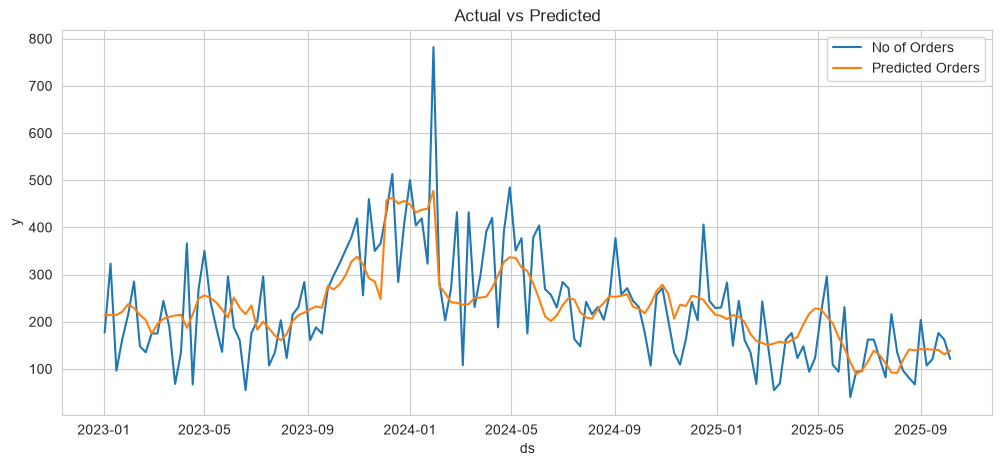

In [60]:
ck = train_pred[0]
plt.figure(figsize=(12,5))
sns.lineplot(data=ck, x='ds', y='y', label='No of Orders')
sns.lineplot(data=ck, x='ds', y='yhat', label='Predicted Orders')
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
df_performance[df_performance['Error'].notna()]['center_meal']

,center_meal,r2_score,mape,Error
3509,92_2104,NaN,NaN,"Found array with 0 sample(s) (shape=(0, 4)) wh..."
3513,73_1571,NaN,NaN,"Found array with 0 sample(s) (shape=(0, 4)) wh..."
3514,73_2956,NaN,NaN,"Found array with 0 sample(s) (shape=(0, 4)) wh..."


In [70]:
df[df['center_meal'].isin(['92_2104', '73_1571', '73_2956'])]

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,center_meal,SBC,date


In [73]:
df[(df['center_id'].isin([92, 73])) & (df['meal_id'].isin([2104, 1571, 2956]))]

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,center_meal,SBC,date


In [69]:
df_test[df_test['center_meal'].isin(['92_2104', '73_1571', '73_2956'])]

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,date,center_meal
10988,1179493,149,92,2104,631.53,629.53,0,0,2025-11-03,92_2104
11722,1032374,149,73,1571,629.53,630.53,0,0,2025-11-03,73_1571
11723,1294006,149,73,2956,629.53,631.53,0,0,2025-11-03,73_2956
15021,1491271,150,73,1571,629.53,631.53,0,0,2025-11-10,73_1571
15022,1333321,150,73,2956,639.23,639.23,0,0,2025-11-10,73_2956
17547,1048344,151,92,2104,629.53,629.53,0,0,2025-11-17,92_2104
18273,1282860,151,73,1571,631.53,630.53,0,0,2025-11-17,73_1571
18274,1101343,151,73,2956,644.14,643.14,0,0,2025-11-17,73_2956
21489,1200089,152,73,2956,655.78,653.78,0,0,2025-11-24,73_2956
24756,1461586,153,73,1571,630.53,629.53,0,0,2025-12-01,73_1571


In [68]:
list1 = ['92_2104', '73_1571', '73_2956']
list(set(list1) & set(center_meals))

['73_2956', '92_2104', '73_1571']

In [64]:
df_test1.tail()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,ds,center_meal,trend,yearly,yhat
32555,1185766,154,162,1247,-0.058310,-0.759536,0.0,0.0,2025-12-08,162_1247,20.595530,8.490415,28.904175
32556,1468256,154,102,1770,0.520900,0.464760,0.0,0.0,2025-12-08,102_1770,12.294817,0.376680,13.782862
32557,1492097,155,55,1902,0.464344,0.113307,0.0,0.0,2025-12-15,55_1902,1.162151,-10.454441,-9.509102
32558,1372749,155,74,1247,-0.181883,-1.019547,0.0,0.0,2025-12-15,74_1247,-10.945846,35.579821,25.440706
32559,1030237,155,139,2577,1.660841,1.649916,0.0,0.0,2025-12-15,139_2577,13.669891,NaN,12.096463
